In [1]:
# 1 Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Estandarización de variables numéricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import f1_score

In [8]:
# Prepare the data for ANOVA
data = {'Concentration': ['2 %', '2 %', '2 %', '2 %', '2 %', '2 %', '2 %', '2 %', '2 %', '2 %', '2 %', '2 %',
                          '4 %', '4 %', '4 %', '4 %', '4 %', '4 %', '4 %', '4 %', '4 %', '4 %', '4 %', '4 %',
                          '8 %', '8 %', '8 %', '8 %', '8 %', '8 %', '8 %', '8 %', '8 %', '8 %', '8 %', '8 %'],
        'Pressure': [400, 400, 500, 500, 650, 650, 400, 400, 500, 500, 650, 650,
                     400, 400, 500, 500, 650, 650, 400, 400, 500, 500, 650, 650,
                     400, 400, 500, 500, 650, 650, 400, 400, 500, 500, 650, 650],
        'Time': [3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4,
                 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4,
                 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4],
        'Resistance': [196.6, 196.0, 197.7, 196.0, 199.8, 199.4, 198.4, 198.6, 199.6, 200.4, 200.6, 200.9,
                       198.5, 197.2, 196.0, 196.9, 198.4, 197.6, 197.5, 198.1, 198.7, 198.0, 199.6, 199.0,
                       197.5, 196.6, 195.6, 196.2, 197.4, 198.1, 197.6, 198.4, 197.0, 197.8, 198.5, 199.8]}

df_anova = pd.DataFrame(data)
print(df_anova)

   Concentration  Pressure  Time  Resistance
0            2 %       400     3       196.6
1            2 %       400     3       196.0
2            2 %       500     3       197.7
3            2 %       500     3       196.0
4            2 %       650     3       199.8
5            2 %       650     3       199.4
6            2 %       400     4       198.4
7            2 %       400     4       198.6
8            2 %       500     4       199.6
9            2 %       500     4       200.4
10           2 %       650     4       200.6
11           2 %       650     4       200.9
12           4 %       400     3       198.5
13           4 %       400     3       197.2
14           4 %       500     3       196.0
15           4 %       500     3       196.9
16           4 %       650     3       198.4
17           4 %       650     3       197.6
18           4 %       400     4       197.5
19           4 %       400     4       198.1
20           4 %       500     4       198.7
21        

In [9]:
df_anova.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Concentration  36 non-null     object 
 1   Pressure       36 non-null     int64  
 2   Time           36 non-null     int64  
 3   Resistance     36 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.3+ KB


In [14]:
# Asegurar categorías (evita que '2 %' se trate como texto libre)
df = df_anova.copy()
df["Concentration"] = df["Concentration"].astype("category")
df["Pressure"]      = df["Pressure"].astype("category")
df["Time"]          = df["Time"].astype("category")

# Comprobar balance (2 réplicas por combinación)
conteo = df.groupby(["Concentration","Pressure","Time"]).size().unstack("Time")
print(conteo)  # Debe mostrar 2 en cada celda de tiempo=3 y tiempo=4
print("Tamaño:", df.shape)


Time                    3  4
Concentration Pressure      
2 %           400       2  2
              500       2  2
              650       2  2
4 %           400       2  2
              500       2  2
              650       2  2
8 %           400       2  2
              500       2  2
              650       2  2
Tamaño: (36, 4)


/tmp/ipython-input-3506490860.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo = df.groupby(["Concentration","Pressure","Time"]).size().unstack("Time")


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Concentration  36 non-null     category
 1   Pressure       36 non-null     category
 2   Time           36 non-null     category
 3   Resistance     36 non-null     float64 
dtypes: category(3), float64(1)
memory usage: 916.0 bytes


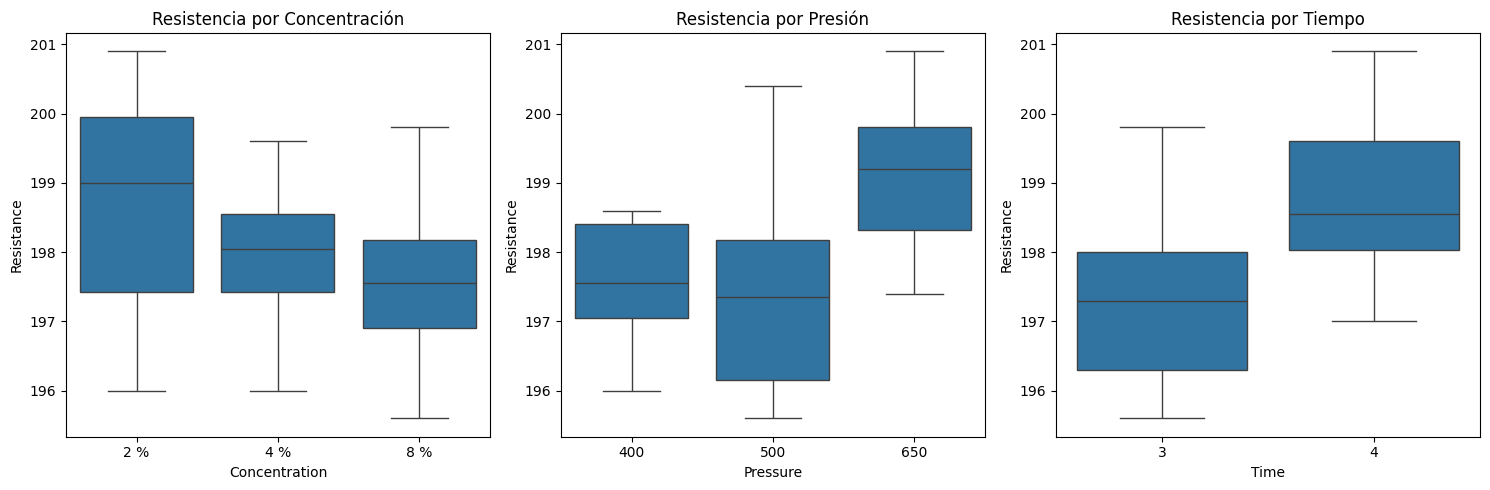

In [29]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

sns.boxplot(data=df, x="Concentration", y="Resistance", ax=axs[0])
axs[0].set_title("Resistencia por Concentración")

sns.boxplot(data=df, x="Pressure", y="Resistance", ax=axs[1])
axs[1].set_title("Resistencia por Presión")

sns.boxplot(data=df, x="Time", y="Resistance", ax=axs[2])
axs[2].set_title("Resistencia por Tiempo")

plt.tight_layout()
plt.show()

In [23]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols("Resistance ~ C(Concentration)*C(Pressure)*C(Time)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                         sum_sq    df          F        PR(>F)
C(Concentration)                       7.763889   2.0  10.619301  8.995614e-04
C(Pressure)                           19.373889   2.0  26.499240  4.327241e-06
C(Time)                               20.250000   1.0  55.395137  6.745340e-07
C(Concentration):C(Pressure)           6.091111   4.0   4.165653  1.462624e-02
C(Concentration):C(Time)               2.081667   2.0   2.847264  8.425969e-02
C(Pressure):C(Time)                    2.195000   2.0   3.002280  7.495643e-02
C(Concentration):C(Pressure):C(Time)   1.973333   4.0   1.349544  2.903053e-01
Residual                               6.580000  18.0        NaN           NaN


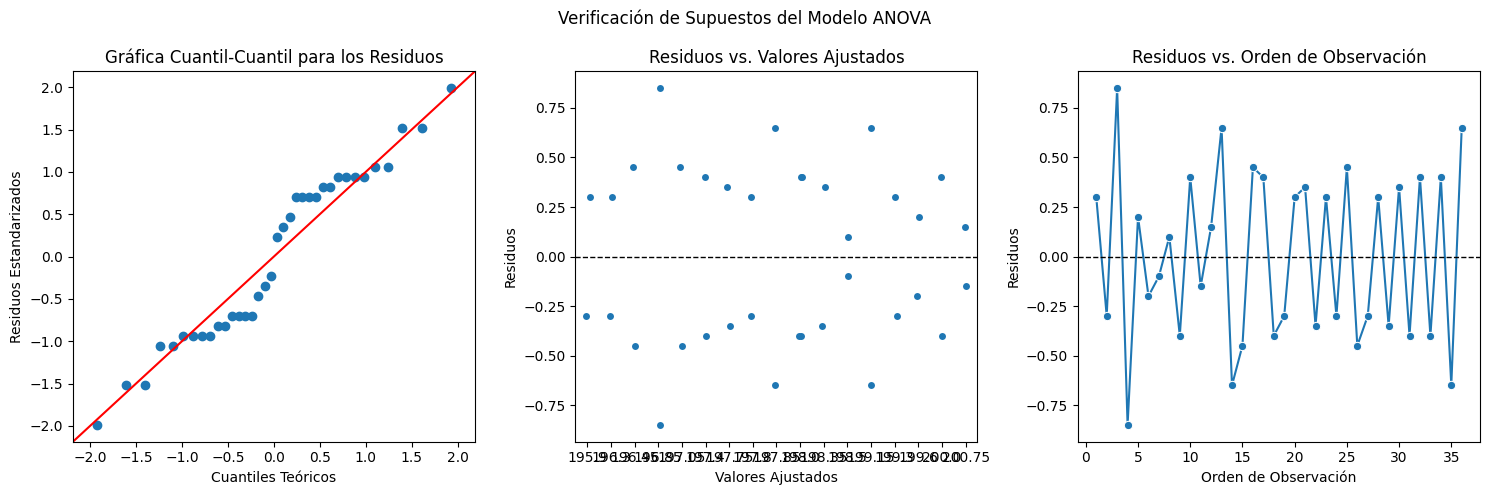

In [24]:
# Verificación de Supuestos

fig, axs = plt.subplots(ncols=3,figsize=(15,5))

res = model.resid
sm.qqplot(res,fit=True ,line='45',ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")

adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res,ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')


sns.lineplot(x=res.index+1,y=res,marker='o',ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')

fig.suptitle('Verificación de Supuestos del Modelo ANOVA')
plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

In [41]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Presión dentro de cada Concentración (pooling sobre Time)
for c in df["Concentration"].unique():
    sub = df[df["Concentration"] == c]
    print(f"\nTukey: Pressure | Concentration={c}")
    print(pairwise_tukeyhsd(endog=sub["Resistance"], groups=sub["Pressure"], alpha=0.05))

# Concentración dentro de cada Presión (pooling sobre Time)
for p in df["Pressure"].unique():
    sub = df[df["Pressure"] == p]
    print(f"\nTukey: Concentration | Pressure={p}")
    print(pairwise_tukeyhsd(endog=sub["Resistance"], groups=sub["Concentration"], alpha=0.05))



Tukey: Pressure | Concentration=2 %
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   400    500    1.025 0.5835 -1.7805 3.8305  False
   400    650    2.775 0.0524 -0.0305 5.5805  False
   500    650     1.75 0.2429 -1.0555 4.5555  False
---------------------------------------------------

Tukey: Pressure | Concentration=4 %
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   400    500   -0.425 0.7919 -2.2245 1.3745  False
   400    650    0.825 0.4402 -0.9745 2.6245  False
   500    650     1.25 0.1833 -0.5495 3.0495  False
---------------------------------------------------

Tukey: Pressure | Concentration=8 %
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   40

In [40]:
# Promedia sobre Time para desglosar la interacción C×P
df_cp = (df.groupby(["Concentration","Pressure"])["Resistance"]
           .mean().reset_index())

# Tukey: Pressure dentro de cada Concentration
for c in df_cp["Concentration"].unique():
    sub = df_cp[df_cp["Concentration"]==c]
    print(f"\nTukey - Pressure | Concentration={c}")
    print(pairwise_tukeyhsd(sub["Resistance"], sub["Pressure"], alpha=0.05))

# Tukey: Concentration dentro de cada Pressure
for p in df_cp["Pressure"].unique():
    sub = df_cp[df_cp["Pressure"]==p]
    print(f"\nTukey - Concentration | Pressure={p}")
    print(pairwise_tukeyhsd(sub["Resistance"], sub["Concentration"], alpha=0.05))



Tukey - Pressure | Concentration=2 %
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
   400    500    1.025   nan   nan   nan  False
   400    650    2.775   nan   nan   nan  False
   500    650     1.75   nan   nan   nan  False
-----------------------------------------------

Tukey - Pressure | Concentration=4 %
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
   400    500   -0.425   nan   nan   nan  False
   400    650    0.825   nan   nan   nan  False
   500    650     1.25   nan   nan   nan  False
-----------------------------------------------

Tukey - Pressure | Concentration=8 %
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
   400    500   -0.875   nan   nan   nan  False
   400    

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


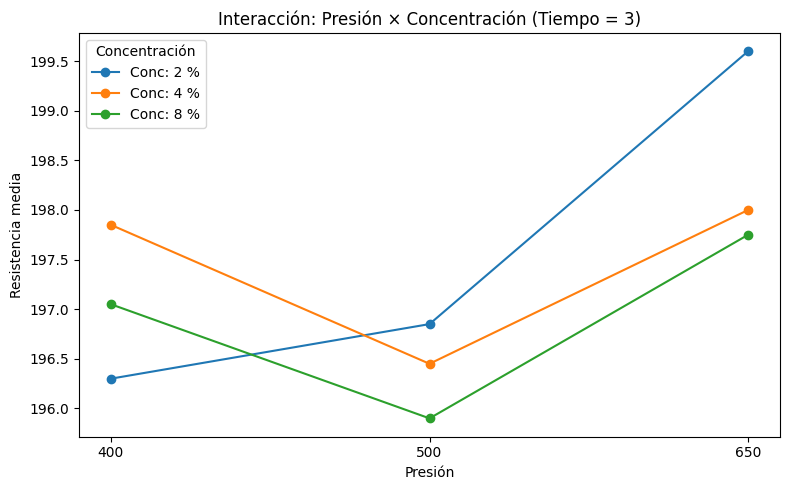

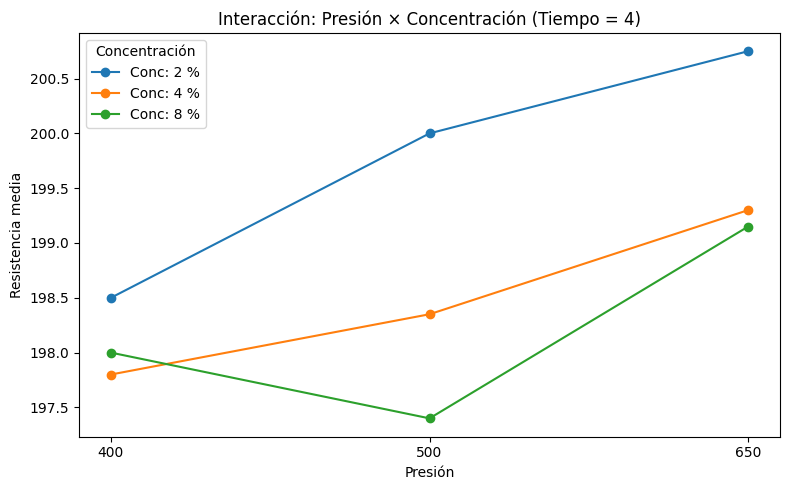

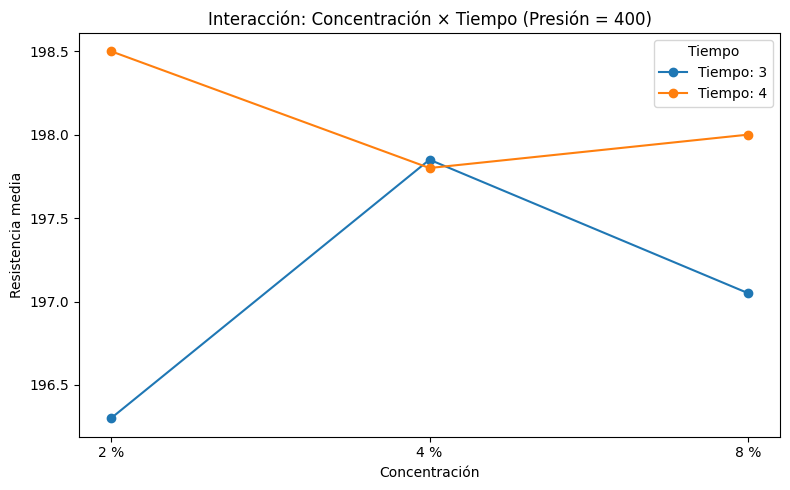

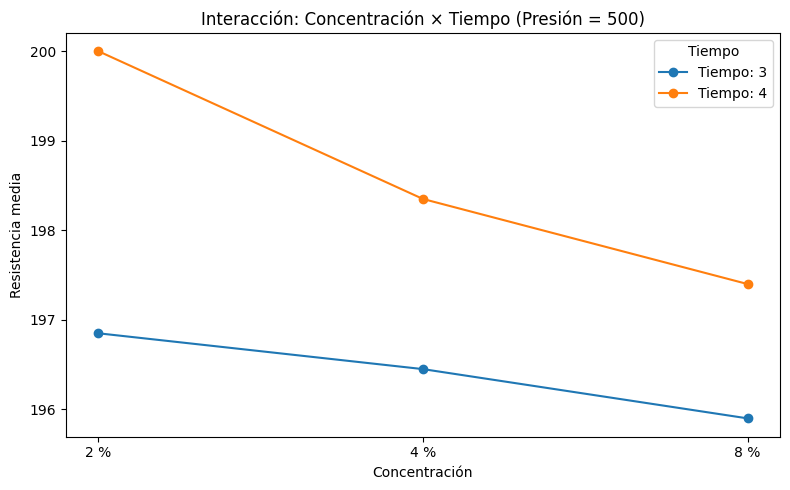

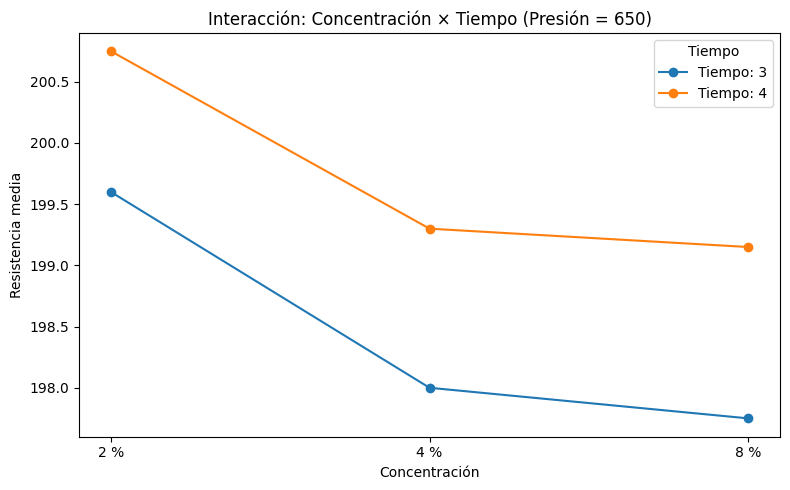

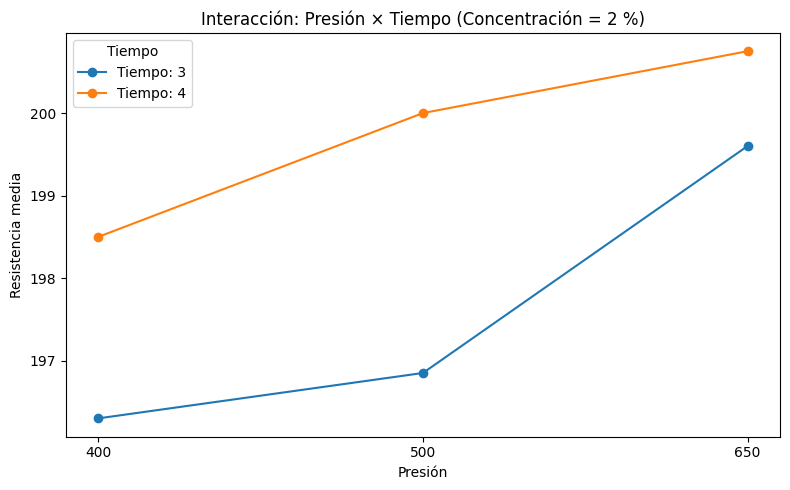

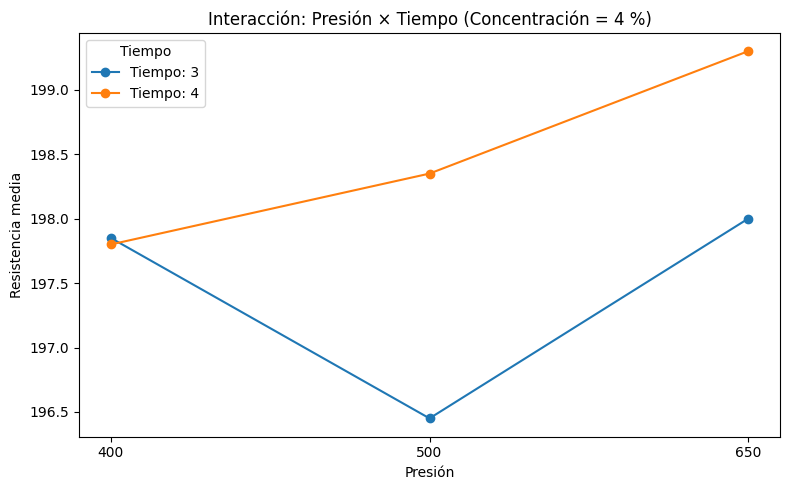

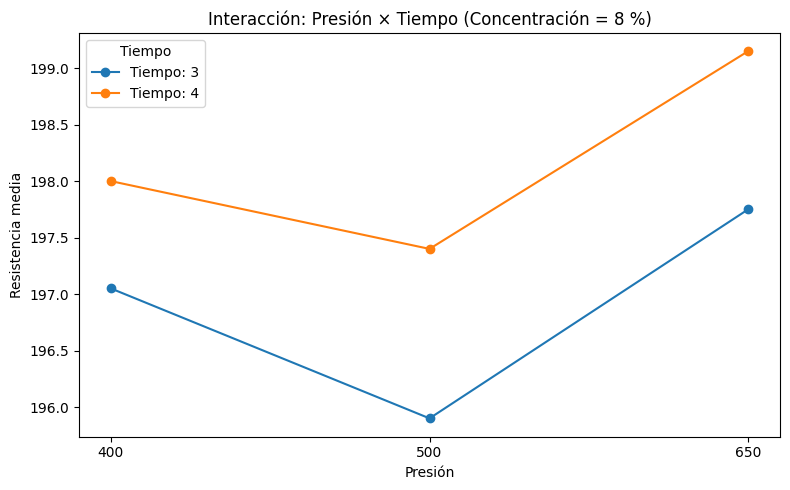

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_plot = df.copy()

# Strings for plotting and iteration
df_plot["Concentration_str"] = df_plot["Concentration"].astype(str)
df_plot["Pressure_str"]      = df_plot["Pressure"].astype(str)
df_plot["Time_str"]          = df_plot["Time"].astype(str)

# === Concentración × Presión | Time (2 paneles) ===
for t in df_plot["Time_str"].unique():
    sub = df_plot[df_plot["Time_str"] == t]
    means = (sub.groupby(["Pressure_str","Concentration_str"])["Resistance"]
                .mean().unstack("Concentration_str"))
    # Ensure order in X-axis for Pressure (if needed, define order manually)
    # means = means.loc[["400","500","650"]]

    plt.figure(figsize=(8,5))
    for conc in means.columns:
        plt.plot(means.index, means[conc].values, marker="o", label=f"Conc: {conc}")
    plt.xlabel("Presión"); plt.ylabel("Resistencia media")
    plt.title(f"Interacción: Presión × Concentración (Tiempo = {t})")
    plt.legend(title="Concentración");
    # plt.ylim(196, 201)  # 3) opcional: mismo rango Y
    plt.tight_layout(); plt.show()

# === Concentración × Tiempo | Pressure (3 paneles) ===
for p in df_plot["Pressure_str"].unique():
    sub = df_plot[df_plot["Pressure_str"] == p]
    means = (sub.groupby(["Concentration_str","Time_str"])["Resistance"]
                .mean().unstack("Time_str"))
    # Ensure order in X-axis for Concentration (if needed, define order manually)
    # means = means.loc[["2 %","4 %","8 %"]]

    plt.figure(figsize=(8,5))
    for time in means.columns:
        plt.plot(means.index, means[time].values, marker="o", label=f"Tiempo: {time}")
    plt.xlabel("Concentración"); plt.ylabel("Resistencia media")
    plt.title(f"Interacción: Concentración × Tiempo (Presión = {p})")
    plt.legend(title="Tiempo");
    # plt.ylim(196, 201)
    plt.tight_layout(); plt.show()

# === Presión × Tiempo | Concentration (3 paneles) ===
for c in df_plot["Concentration_str"].unique():
    sub = df_plot[df_plot["Concentration_str"] == c]
    means = (sub.groupby(["Pressure_str","Time_str"])["Resistance"]
                .mean().unstack("Time_str"))
    # Ensure order in X-axis for Pressure (if needed, define order manually)
    # means = means.loc[["400","500","650"]]

    plt.figure(figsize=(8,5))
    for time in means.columns:
        plt.plot(means.index, means[time].values, marker="o", label=f"Tiempo: {time}")
    plt.xlabel("Presión"); plt.ylabel("Resistencia media")
    plt.title(f"Interacción: Presión × Tiempo (Concentración = {c})")
    plt.legend(title="Tiempo");
    # plt.ylim(196, 201)
    plt.tight_layout(); plt.show()

## CONDICIONES DE OPERACIÓN

In [49]:
cell_means = (df.groupby(["Concentration","Pressure","Time"])["Resistance"]
                .mean().reset_index()
                .sort_values("Resistance", ascending=False))
print(cell_means.head(10))


   Concentration Pressure Time  Resistance
5            2 %      650    4      200.75
3            2 %      500    4      200.00
4            2 %      650    3      199.60
11           4 %      650    4      199.30
17           8 %      650    4      199.15
1            2 %      400    4      198.50
9            4 %      500    4      198.35
10           4 %      650    3      198.00
13           8 %      400    4      198.00
6            4 %      400    3      197.85


In [53]:
import numpy as np
from scipy.stats import t

cell_stats = (df.groupby(["Concentration","Pressure","Time"])["Resistance"]
                .agg(n="count", mean="mean", sd="std")
                .reset_index())

# IC95% = mean ± t_{0.975, n-1} * (sd/√n)
cell_stats["se"]   = cell_stats["sd"] / np.sqrt(cell_stats["n"])
cell_stats["tval"] = cell_stats["n"].apply(lambda n: t.ppf(0.975, n-1) if n>1 else np.nan)
cell_stats["ci95"] = cell_stats["se"] * cell_stats["tval"]

top = cell_stats.sort_values("mean", ascending=False)

best   = top.iloc[0]
second = top.iloc[1]

print("\nComparación rápida de las 2 mejores celdas:")
print(best[["Concentration","Pressure","Time","mean","ci95"]])
print(second[["Concentration","Pressure","Time","mean","ci95"]])

gap  = abs(best["mean"] - second["mean"])
band = best["ci95"] + second["ci95"]
print(f"\nDiferencia de medias = {gap:.3f}, suma de bandas 95% = {band:.3f}")



Comparación rápida de las 2 mejores celdas:
Concentration         2 %
Pressure              650
Time                    4
mean               200.75
ci95             1.905931
Name: 5, dtype: object
Concentration         2 %
Pressure              500
Time                    4
mean                200.0
ci95             5.082482
Name: 3, dtype: object

Diferencia de medias = 0.750, suma de bandas 95% = 6.988
